# Сравнение средних и непараметрические тесты

In [1]:
import pandas as pd
from scipy import stats
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

В файле Worldbank.xlsx содержаться данные Всемирного банка по разным статьям экспорта по странам за 2018 и 2019 годы.

**Описание переменных**

- CountryName	- Country Name
- CountryCode	- Country Code
- high_income	- High income countries (принимает значение 1, если страна относится к странам с высоким доходом, 0 – если не относится)
- income	- Income (принимает три значения: high income, middle income, low income)
- development	- Developed or developing country (принимает два значения: developing, developed)

**Столбцы с данными на 2018 год:**
- Agriculturalrawmaterialsexpor	- Agricultural raw materials exports (% of merchandise exports)
- ArmsexportsSIPRItrendindica	- Arms exports (SIPRI trend indicator values)
- Commercialserviceexportscurr	- Commercial service exports (current US dollars)
- Communicationscomputeretc	- Communications, computer, etc. (% of service exports, BoP)
- Exportsofgoodsandservices	- Exports of goods and services (% of GDP) 
- Exportsofgoodsandservicesa - Exports of goods and services (annual percent growth) 
- ExportsofgoodsandservicesB - Exports of goods and services (BoP, current US dollars) 
- Exportsofgoodsandservicesc - Exports of goods and services (constant 2010 US dollarc) 
- Foodexportsofmerchandisee	- Food exports (% of merchandise exports) 
- GoodsexportsBoPcurrentUS	- Goods exports (BoP, current US dollars) 
- Fuelexportsofmerchandisee	- Fuel exports (% of merchandise exports) 
- Hightechnologyexportsofma	- High-technology exports (% of manufactured exports)
- Hightechnologyexportscurrent	- High-technology exports (current US dollars) 
- TaxesonexportscurrentLCU	- Taxes on exports (current LCU) 
- Transportservicesofservice	- Transport services (% of service exports, BoP)
- Travelservicesofcommercial	- Travel services (% of commercial service exports)
- Travelservicesofserviceex	- Travel services (% of service exports, BoP)


**Столбцы с данными на 2019 год:**
- Travelservicesofcommercial2019 - Travel services (% of commercial service exports)
- Agriculturalrawmaterialsexpo2019 -  Agricultural raw materials exports (% of merchandise exports)
- Communicationscomputeretc2019 - Communications, computer, etc. (% of service imports, BoP)
- Transportservicesofservice2019 - Transport services (% of service exports, BoP)

In [2]:
df = pd.read_excel('Worldbank.xlsx')
df #загружаем данные из файла 

,CountryName,CountryCode,Agriculturalrawmaterialsexpor,ArmsexportsSIPRItrendindica,Commercialserviceexportscurr,Communicationscomputeretc,Exportsofgoodsandservices,Exportsofgoodsandservicesa,ExportsofgoodsandservicesB,Exportsofgoodsandservicesc,...,Transportservicesofservice,Travelservicesofcommercial,Travelservicesofserviceex,high_income,income,development,Travelservicesofcommercial2019,Agriculturalrawmaterialsexpo2019,Communicationscomputeretc2019,Transportservicesofservice2019
0,Afghanistan,AFG,17.113304,NaN,6.230657e+08,28.402324,NaN,NaN,1.611540e+09,NaN,...,24.602029,4.482772,3.793358,0,low income,developing,14.367959,NaN,6.467647,16.344074
1,Albania,ALB,0.313849,NaN,3.574339e+09,16.058391,31.684671,3.196598,4.784712e+09,4.807222e+09,...,8.443837,61.150507,60.361848,0,middle income,developing,62.216690,NaN,5.979548,7.154605
2,Algeria,DZA,NaN,NaN,NaN,NaN,25.623547,-4.300000,NaN,5.296803e+10,...,NaN,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN
3,American Samoa,ASM,NaN,NaN,NaN,NaN,68.867925,14.325843,NaN,3.321704e+08,...,NaN,NaN,NaN,0,middle income,developing,NaN,NaN,NaN,NaN
4,Andorra,AND,1.551347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,high income,developed,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,high income,developing,NaN,NaN,NaN,NaN
213,West Bank and Gaza,PSE,NaN,NaN,5.608593e+08,36.257881,19.865352,7.878720,2.903485e+09,2.456322e+09,...,1.625164,43.720375,40.034937,0,middle income,developing,45.238319,0.913553,10.780279,1.079660
214,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,low income,developing,NaN,0.017167,NaN,NaN
215,Zambia,ZMB,0.903647,NaN,9.532642e+08,3.739193,37.422550,NaN,9.982666e+09,NaN,...,5.641202,77.857990,77.857990,0,middle income,developing,80.805321,1.332663,9.384435,4.395867


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CountryName                       217 non-null    object 
 1   CountryCode                       217 non-null    object 
 2   Agriculturalrawmaterialsexpor     126 non-null    float64
 3   ArmsexportsSIPRItrendindica       40 non-null     float64
 4   Commercialserviceexportscurr      164 non-null    float64
 5   Communicationscomputeretc         159 non-null    float64
 6   Exportsofgoodsandservices         168 non-null    float64
 7   Exportsofgoodsandservicesa        151 non-null    float64
 8   ExportsofgoodsandservicesB        163 non-null    float64
 9   Exportsofgoodsandservicesc        148 non-null    float64
 10  Foodexportsofmerchandisee         127 non-null    float64
 11  GoodsexportsBoPcurrentUS          164 non-null    float64
 12  Fuelexpo

# Описательная статистика и графики

В таблице рассчитаны среднее арифметическое и стандартное отклонение по переменной Travel services (% of service exports, BoP) в трёх группах стран по доходу.

In [4]:
df.pivot_table(index='income', values=['Travelservicesofserviceex'], aggfunc=['mean', 'std'])

,mean,std
,Travelservicesofserviceex,Travelservicesofserviceex
income,,
high income,32.802454,22.581276
low income,34.703687,28.395078
middle income,50.091685,23.630570


На графике показаны средние значения переменной по 3 группам.

<Axes: xlabel='income'>

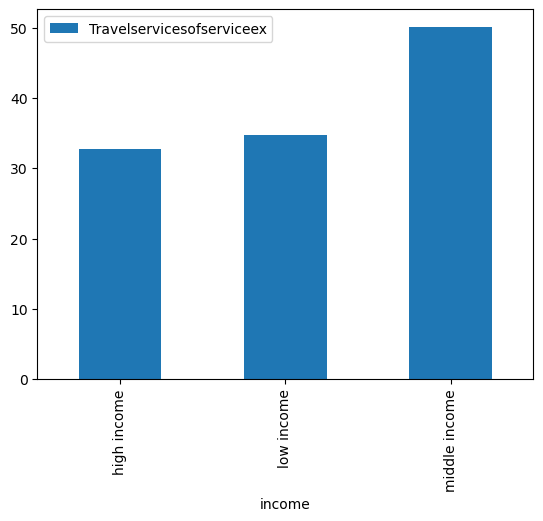

In [5]:
df.groupby('income')[['Travelservicesofserviceex']].mean().plot(kind='bar')

Ниже приведен график "Столбики ошибок". Отражается среднее и стандартное отклонение по показателю в каждой группе.

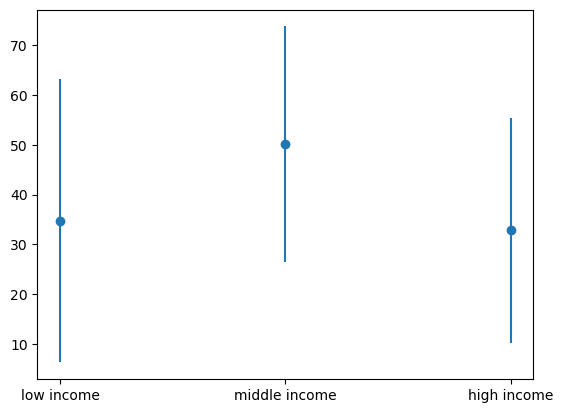

In [6]:
x = ['low income', 'middle income', 'high income']
y = [df[df.income=='low income']['Travelservicesofserviceex'].mean(), df[df.income=='middle income']['Travelservicesofserviceex'].mean(), df[df.income=='high income']['Travelservicesofserviceex'].mean()]
e = [df[df.income=='low income']['Travelservicesofserviceex'].std(), df[df.income=='middle income']['Travelservicesofserviceex'].std(), df[df.income=='high income']['Travelservicesofserviceex'].std()]
plt.errorbar(x, y, yerr=e, fmt='o')
plt.show()

Ящичковая диаграмма

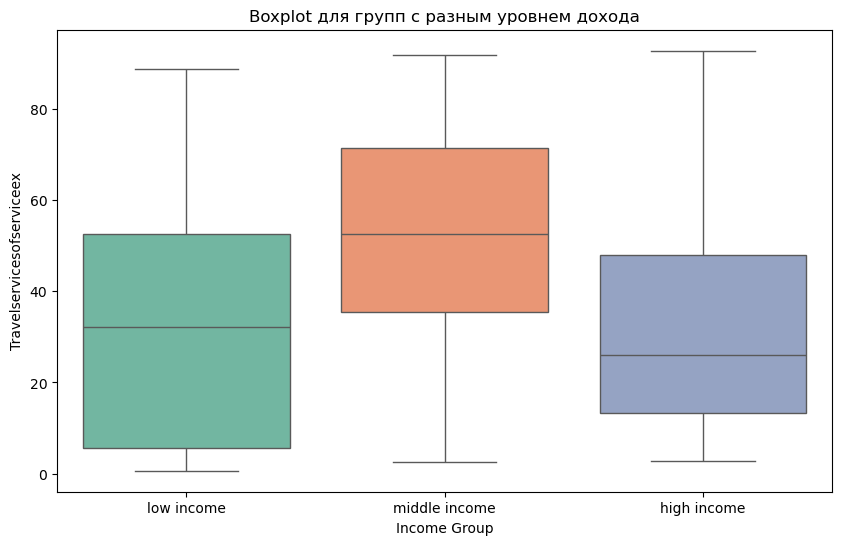

In [7]:
plt.figure(figsize=(10, 6)) #Boxplot
sns.boxplot(x='income', y='Travelservicesofserviceex', data=df, palette="Set2")
plt.title('Boxplot для групп с разным уровнем дохода')
plt.xlabel('Income Group')
plt.ylabel('Travelservicesofserviceex')
plt.show()

Стрип-плот

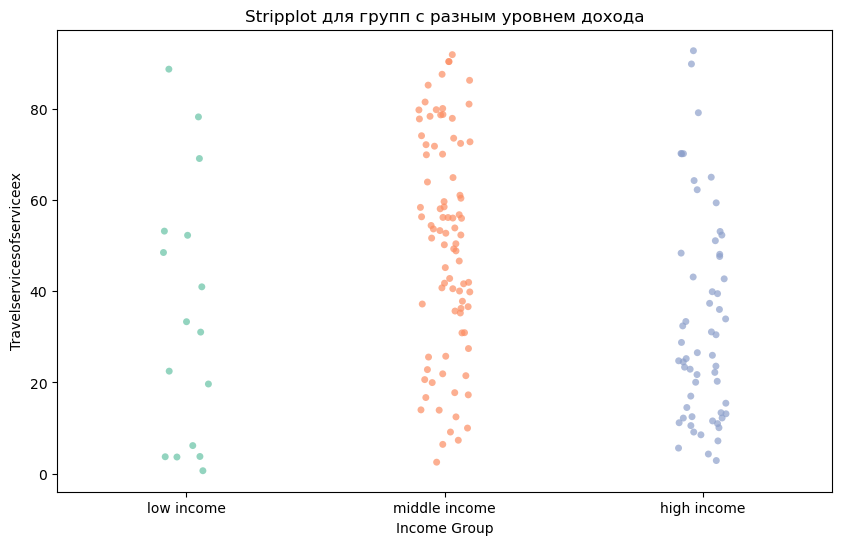

In [8]:
plt.figure(figsize=(10, 6)) # Stripplot 
sns.stripplot(x='income', y='Travelservicesofserviceex', data=df, jitter=True, palette="Set2", alpha=0.7)
plt.title('Stripplot для групп с разным уровнем дохода')
plt.xlabel('Income Group')
plt.ylabel('Travelservicesofserviceex')
plt.show()

## Проверка на нормальность

In [9]:
stats.kstest(df.Travelservicesofserviceex.dropna(), 'norm', args=(df.Travelservicesofserviceex.mean(), df.Travelservicesofserviceex.std()))

KstestResult(statistic=0.08336118017262839, pvalue=0.2015993092471281, statistic_location=25.959672299646304, statistic_sign=1)

H0:  Распределение переменной процент экспорта туристических услуг от экспорта всех услуг не отличается от нормального.

H1: Распределение переменной процент экспорта туристических услуг от экспорта всех услуг отличается от нормального.

p-value > 0.05, гипотеза H1 отклоняется, а H0 не отклоняется

**Вывод:** распределение переменной не отличается статистически значимо от нормального, значит для сравнения средних значений переменной в группах можно использовать t-тесты.

<Axes: xlabel='Travelservicesofserviceex', ylabel='Density'>

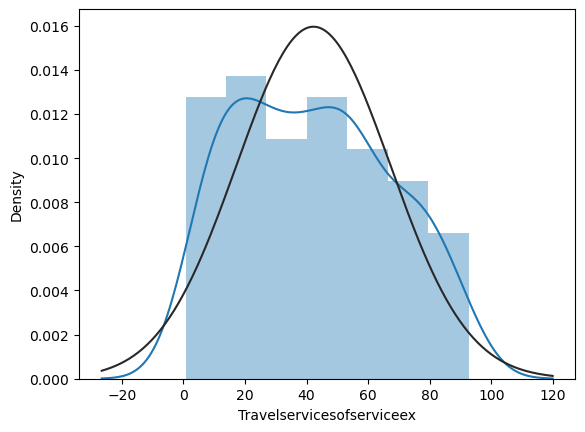

In [10]:
sns.distplot(df.Travelservicesofserviceex.dropna(), fit=stats.norm)  

# t-test для двух независимых выборок

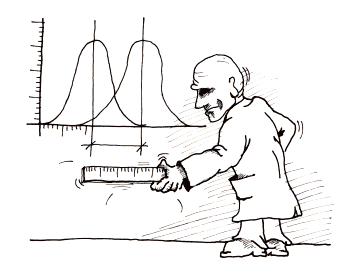

In [13]:
from IPython.display import Image
Image("picture.png")

In [14]:
df.groupby('high_income')['Travelservicesofserviceex'].describe()
#сравниваем значение показателя Travel services (% of service exports, BoP) в двух группах стран (относящихся и не относящихся к станам с высоким доходом)

,count,mean,std,min,25%,50%,75%,max
high_income,,,,,,,,
0,102.0,47.677881,24.926204,0.674764,28.292903,50.277136,69.668599,91.810856
1,59.0,32.802454,22.581276,2.904751,13.264232,25.959672,47.836613,92.670309


In [15]:
group1 = df[df['high_income']==0]['Travelservicesofserviceex']
group2 = df[df['high_income']==1]['Travelservicesofserviceex']

In [16]:
stats.ttest_ind(group1.dropna(), group2.dropna())

TtestResult(statistic=3.774111310824177, pvalue=0.00022629507895983238, df=159.0)

H0: Средние значения переменной процент экспорта туристических услуг от экспорта всех услуг для стран с высоким доходом и других стран не отличаются.

H1: Средние значения переменной процент экспорта туристических услуг от экспорта всех услуг для стран с высоким доходом и других стран отличаются.

**Вывод:** p-value < 0.05, гипотеза H1 принимается, средние различаются.

### Тест Левена на равенство дисперсий

In [17]:
df = pd.read_excel('Worldbank.xlsx')
stats.levene(group1.dropna(), group2.dropna())

LeveneResult(statistic=1.523384923263628, pvalue=0.2189290895038922)

H0: Дисперсии переменной процент экспорта туристических услуг от экспорта всех услуг для стран с высоким доходом и других стран не отличаются.

H1: Дисперсии переменной процент экспорта туристических услуг от экспорта всех услуг для стран с высоким доходом и других стран отличаются.

**Вывод:** p-value > 0.05, гипотеза H1 отклоняется, дисперсии в двух группах не различаются.

In [18]:
df = pd.read_excel('Worldbank.xlsx')
stats.ttest_ind(group1.dropna(), group2.dropna(), equal_var=False) #если бы дисперсии в группах различались
#в этом случае используется t-критерий с поправкой Уэлча и степени свободы рассчитываются иначе, они меньше, чем при стандартном расчёте

TtestResult(statistic=3.8753416780837773, pvalue=0.0001674317761500791, df=131.15501941338377)

# t-test для одной выборки

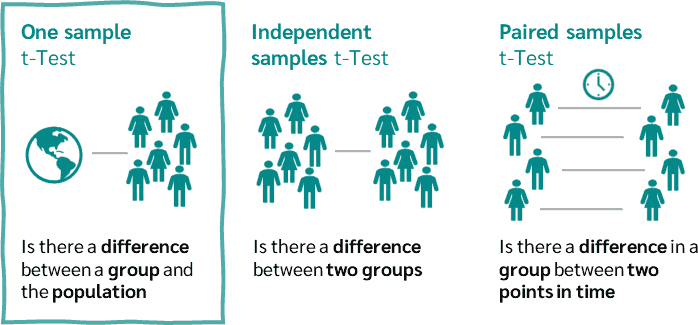

In [19]:
Image("picture2.png")

In [20]:
df = pd.read_excel('Worldbank.xlsx')
stats.ttest_1samp(df['Travelservicesofserviceex'].dropna(), 40)

TtestResult(statistic=1.1267449103278864, pvalue=0.2615373786541348, df=160)

H0: Среднее значение переменной процент экспорта туристических услуг от экспорта всех услуг не отличается от 40.

H1: Среднее значение переменной процент экспорта туристических услуг от экспорта всех услуг отличается от 40.

**Вывод:** p-value > 0.05, гипотеза H1 отклоняется, среднее значение статистически значимо не отличается от 40

In [21]:
stats.ttest_1samp(df['Travelservicesofserviceex'].dropna(), 140)

TtestResult(statistic=-49.476227090249566, pvalue=6.904596284425387e-99, df=160)

H0: Среднее значение переменной процент экспорта туристических услуг от экспорта всех услуг не отличается от 140.

H1: Среднее значение переменной процент экспорта туристических услуг от экспорта всех услуг отличается от 140.

**Вывод:** p-value < 0.05, гипотеза H1 принимается, среднее значение статистически значимо отличается от 140

# t-test для двух связанных выборок

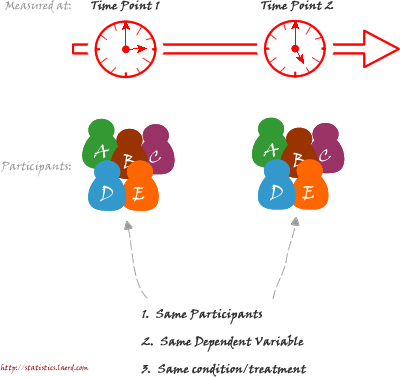

In [22]:
Image("picture3.gif")

### Проверка на нормальность

In [23]:
df = pd.read_excel('Worldbank.xlsx')
stats.kstest(df.Travelservicesofcommercial.dropna(), 'norm', args=(df.Travelservicesofcommercial.mean(), df.Travelservicesofcommercial.std()))

KstestResult(statistic=0.09553969641122712, pvalue=0.09907565566329246, statistic_location=26.643863583617026, statistic_sign=1)

<Axes: xlabel='Travelservicesofcommercial', ylabel='Density'>

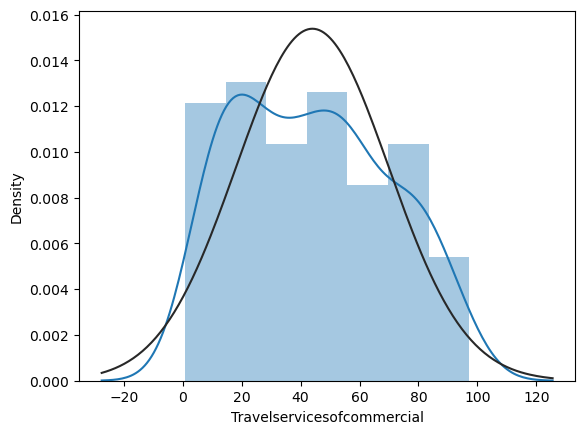

In [24]:
sns.distplot(df.Travelservicesofcommercial.dropna(), fit=stats.norm)  

In [25]:
stats.kstest(df.Travelservicesofcommercial2019.dropna(), 'norm', args=(df.Travelservicesofcommercial2019.mean(), df.Travelservicesofcommercial2019.std()))

KstestResult(statistic=0.10719599483561548, pvalue=0.09146201642540308, statistic_location=27.10015869140625, statistic_sign=1)

<Axes: xlabel='Travelservicesofcommercial2019', ylabel='Density'>

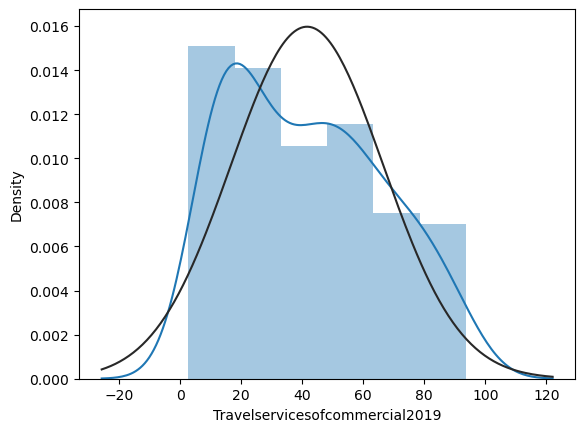

In [26]:
sns.distplot(df.Travelservicesofcommercial2019.dropna(), fit=stats.norm)  

**Вывод:** тесты Колмогорова-Смирнова показали, что распределения значений переменной Travel services (% of commercial service exports), как за 2018, так и за 2019 год не отличаются от нормального.

In [27]:
df = df.dropna(subset=['Travelservicesofcommercial'])
df = df.dropna(subset=['Travelservicesofcommercial2019'])
stats.ttest_rel(df['Travelservicesofcommercial2019'], df['Travelservicesofcommercial'])

TtestResult(statistic=0.6699875444020236, pvalue=0.50407262798285, df=128)

H0: Средние значения переменной процент экспорта туристических услуг от экспорта всех услуг в 2018 и в 2019 годах не отличаются.

H1: Средние значения переменной процент экспорта туристических услуг от экспорта всех услуг в 2018 и в 2019 годах отличаются.

**Вывод:** p-value > 0.05, гипотеза H1 не принимается, средние не отличаются

# ANOVA

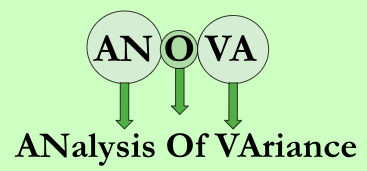

In [28]:
Image("anova6.png")

In [29]:
df = pd.read_excel('Worldbank.xlsx') #заново считываем данные, поскольку ранее удалили пропуски
group_high = df[df['income']=='high income']['Travelservicesofserviceex']
group_low = df[df['income']=='low income']['Travelservicesofserviceex']
group_middle = df[df['income']=='middle income']['Travelservicesofserviceex']

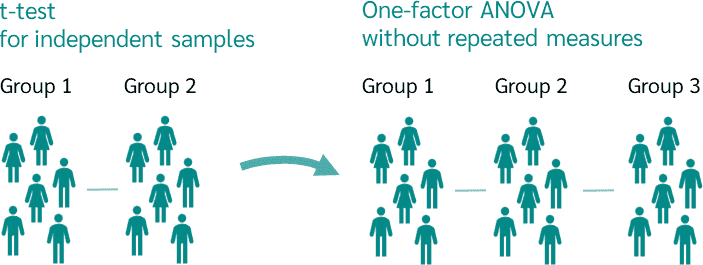

In [30]:
Image("anova3.png")

In [31]:
stats.f_oneway(group_high.dropna(), group_low.dropna(), group_middle.dropna())

F_onewayResult(statistic=10.161981804342945, pvalue=7.052496612669695e-05)

H0: Cредние значения переменной процент экспорта туристических услуг от экспорта всех услуг для стран, относящихся к трём разным группам по уровню дохода, не отличаются.

H1: Cредние значения переменной процент экспорта туристических услуг от экспорта всех услуг для стран, относящихся к трём разным группам по уровню дохода, отличаются.

**Вывод:** p-value < 0.05, принимаем H1, средние отличаются

Чтобы узнать между какими именно парами групп отличаются средние можно провести апостериорный тест, предполагающий проведение нескольких t-тестов для попарного сравнения групп.

In [32]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
df = df.dropna(subset=['Travelservicesofcommercial'])
print(pairwise_tukeyhsd(df['Travelservicesofserviceex'], df['income']))

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
high income    low income   1.9012 0.9565 -13.9387 17.7412  False
high income middle income  17.2892 0.0001   7.7894 26.7891   True
 low income middle income   15.388 0.0484   0.0877 30.6883   True
-----------------------------------------------------------------


**Вывод:** согласно результатам апостериорного теста, статистически значимые отличия средних значений показателя Travel services (% of service exports, BoP) наблюдаются между группами high income и middle income, а также между группами low income и middle income.

# Непараметрические тесты



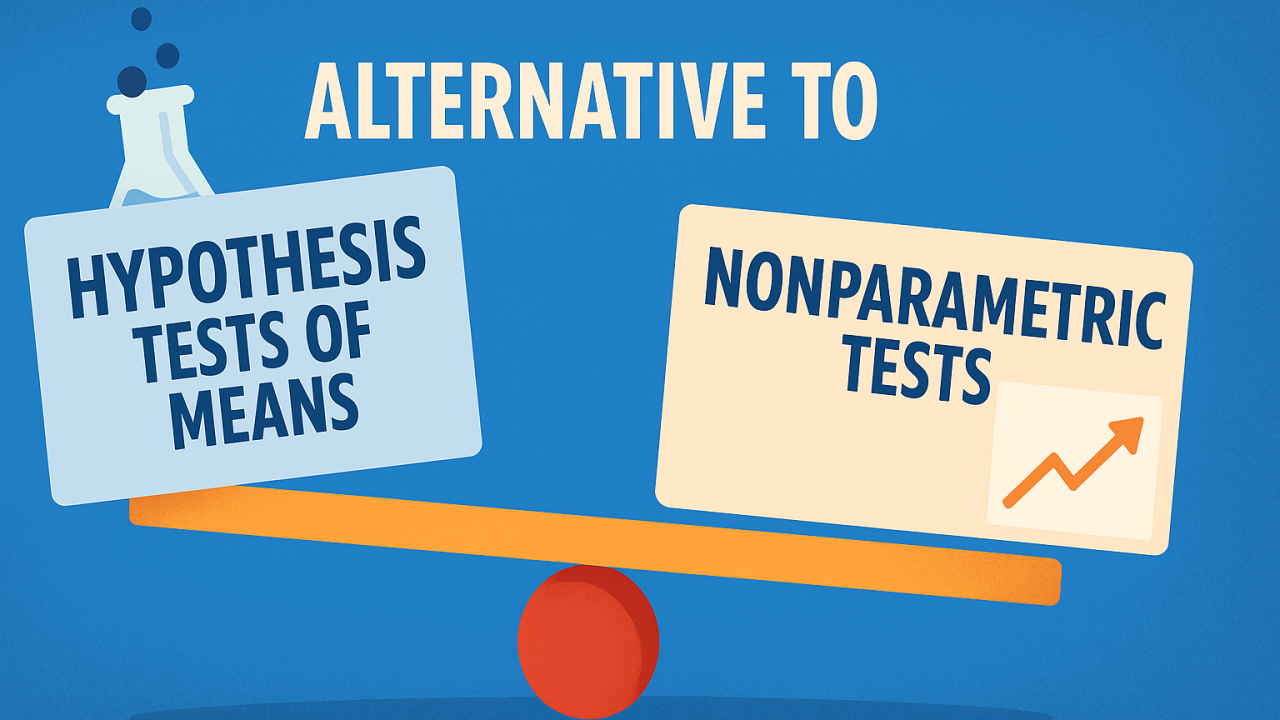

In [33]:
Image("picture4.png", width='400')

## Проверка на нормальность

<Axes: xlabel='Agriculturalrawmaterialsexpor', ylabel='Density'>

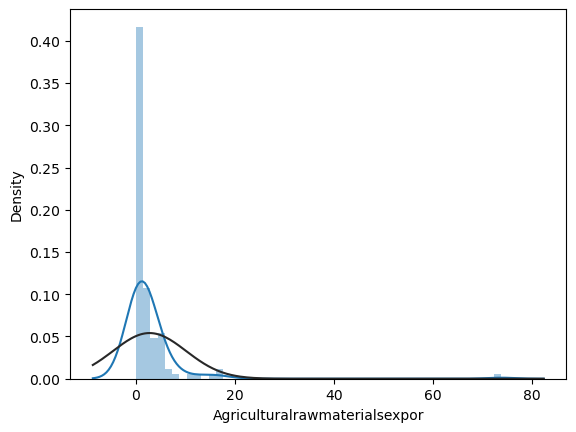

In [34]:
sns.distplot(df.Agriculturalrawmaterialsexpor, fit=stats.norm)  

In [35]:
df = pd.read_excel('Worldbank.xlsx')
df = df.dropna(subset=['Agriculturalrawmaterialsexpor'])
stats.kstest(df.Agriculturalrawmaterialsexpor, 'norm', args=(df.Agriculturalrawmaterialsexpor.mean(), df.Agriculturalrawmaterialsexpor.std()))

KstestResult(statistic=0.347901815635626, pvalue=3.924587324163506e-14, statistic_location=0.0, statistic_sign=-1)

H0: Распределение переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров не отличается от нормального.

H1: Распределение переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров отличается от нормального.

p-value < 0.05, гипотеза H1 принимается, H0 отклоняется 

**Вывод:** распределение переменной статистически значимо отличается от нормального, значит для сравнения значений переменной в группах нужно использовать непараметрические тесты.

# Mann-Whitney U Test

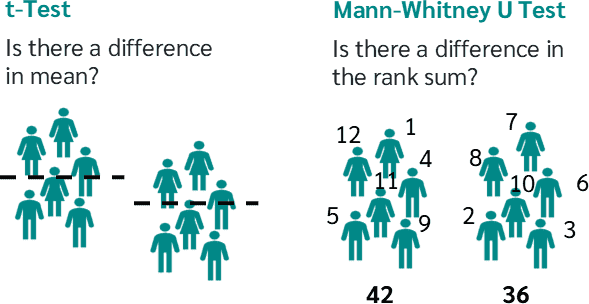

In [36]:
Image("picture5.png")

In [37]:
df = pd.read_excel('Worldbank.xlsx')
group1 = df[df['high_income']==0]['Agriculturalrawmaterialsexpor']
group2 = df[df['high_income']==1]['Agriculturalrawmaterialsexpor']

In [38]:
stats.mannwhitneyu(group1.dropna(), group2.dropna())

MannwhitneyuResult(statistic=2372.0, pvalue=0.04713364008178049)

H0: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров для стран с высоким доходом и других стран не отличаются.

H1: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров для стран с высоким доходом и других стран отличаются.

**Вывод:** p-value < 0.05, гипотеза H1 принимается => значения отличаются

# Wilcoxon signed-rank test

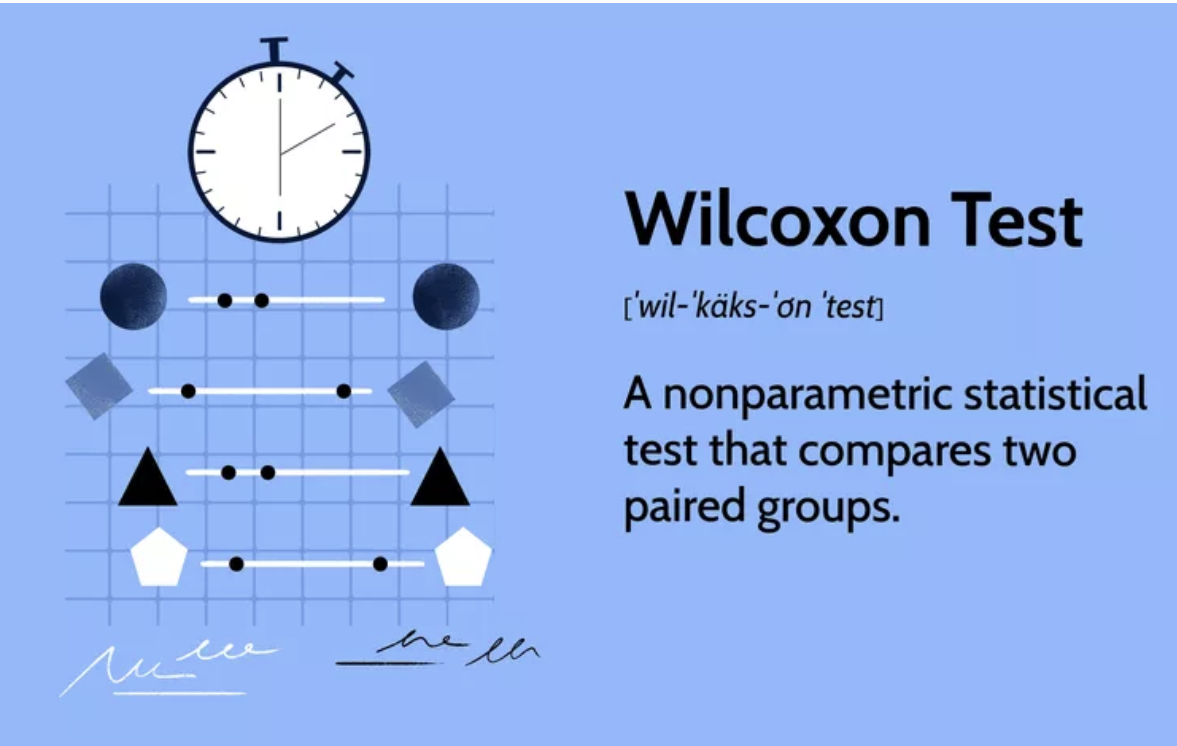

In [39]:
Image("picture6.png", width='400')

In [40]:
df = pd.read_excel('Worldbank.xlsx')
stats.kstest(df.Agriculturalrawmaterialsexpor.dropna(), 'norm', args=(df.Agriculturalrawmaterialsexpor.mean(), df.Agriculturalrawmaterialsexpor.std()))

KstestResult(statistic=0.347901815635626, pvalue=3.924587324163506e-14, statistic_location=0.0, statistic_sign=-1)

<Axes: xlabel='Agriculturalrawmaterialsexpor', ylabel='Density'>

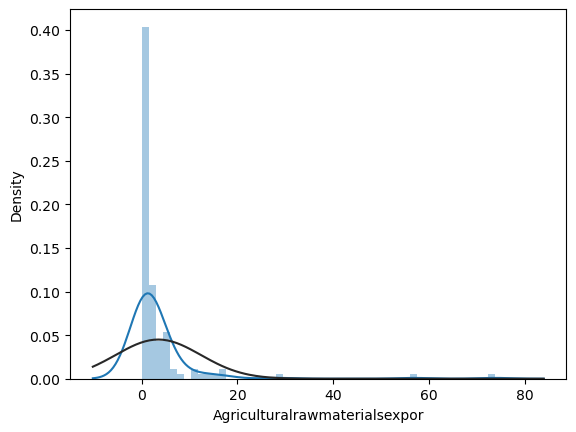

In [41]:
sns.distplot(df.Agriculturalrawmaterialsexpor.dropna(), fit=stats.norm)  

In [42]:
stats.kstest(df.Agriculturalrawmaterialsexpo2019.dropna(), 'norm', args=(df.Agriculturalrawmaterialsexpo2019.mean(), df.Agriculturalrawmaterialsexpo2019.std()))

KstestResult(statistic=0.32723067689605356, pvalue=1.0454902400581402e-12, statistic_location=0.0, statistic_sign=-1)

<Axes: xlabel='Agriculturalrawmaterialsexpo2019', ylabel='Density'>

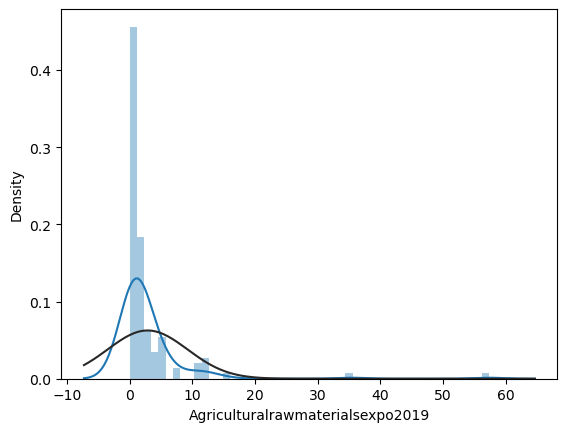

In [43]:
sns.distplot(df.Agriculturalrawmaterialsexpo2019.dropna(), fit=stats.norm)  

**Вывод:** тесты Колмогорова-Смирнова показали, что распределения значений переменной Agricultural raw materials exports (% of merchandise exports), как за 2018, так и за 2019 год отличаются от нормального.

In [44]:
df = pd.read_excel('Worldbank.xlsx')
df = df.dropna(subset=['Agriculturalrawmaterialsexpor'])  # удалить пропуски по одной переменной
df = df.dropna(subset=['Agriculturalrawmaterialsexpo2019'])
stats.wilcoxon(df['Agriculturalrawmaterialsexpor'], df['Agriculturalrawmaterialsexpo2019'])

WilcoxonResult(statistic=2261.0, pvalue=0.025972469414897743)

H0: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров в 2018 и в 2019 годах не отличаются.

H1: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров в 2018 и в 2019 годах  отличаются.

**Вывод:** p-value < 0.05, гипотеза H1 принимается => значения отличаются

# Kruskal-Wallis test

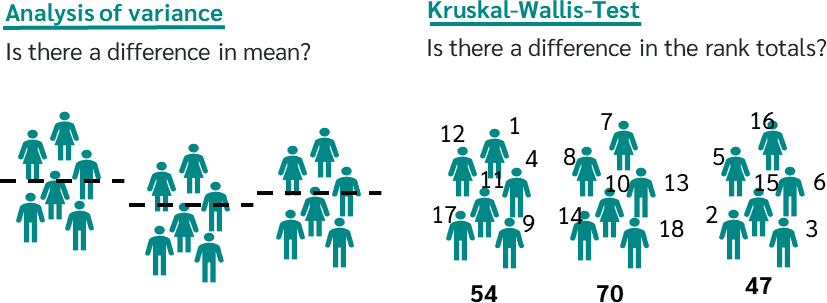

In [45]:
Image("picture7.png")

In [46]:
df = pd.read_excel('Worldbank.xlsx')
df = df.dropna(subset=['Agriculturalrawmaterialsexpor'])
group_high = df[df['income']=='high income']['Agriculturalrawmaterialsexpor']
group_low = df[df['income']=='low income']['Agriculturalrawmaterialsexpor']
group_middle = df[df['income']=='middle income']['Agriculturalrawmaterialsexpor']

In [47]:
stats.kruskal(group_high, group_low, group_middle)

KruskalResult(statistic=5.224116904135485, pvalue=0.07338333211375672)

H0: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров для стран, относящихся к трём разным группам по уровню дохода, не отличаются.

H1: Значения переменной процент экспорта сельскохозяйственного сырья от экспорта всех товаров для стран, относящихся к трём разным группам по уровню дохода, отличаются.

**Вывод:** p-value > 0.05, H1 отклоняется, отличий нет

Чтобы узнать в каких именно группах значения различаются, можно провести тесты Манна_Уитни между всеми возможными парами групп.

In [48]:
from itertools import combinations
list_groups = ['group_high', 'group_low', 'group_middle']
for a, b in combinations(list_groups, 2):
    print(f'{a} and {b}:', stats.mannwhitneyu(eval(a), eval(b))[1])

group_high and group_low: 0.07379972800193849
group_high and group_middle: 0.08722831149411128
group_low and group_middle: 0.23477788683728293


**Вывод:** статистически значимые отличия значений показателя Agricultural raw materials exports (% of merchandise exports) между группами не наблюдаются.

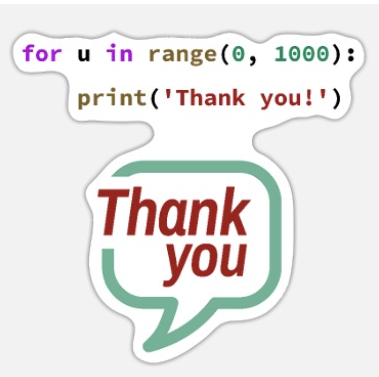

In [49]:
Image("picture8.png")